# Network Science - UDD

## Lab 5 | Práctica en redes tradicionales



#### *Cristian Candia-Castro Vallejos, Ph.D.*

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 

---

Este notebook entrena un **workflow útil y reproducible** para análisis de comunidades en redes unipartitas nativas. La idea es poner en práctica lo esencial de la clase:

- definir con claridad el grafo y su representación
- correr un método práctico (`Louvain`, y `Leiden`)
- evaluar estabilidad entre múltiples `seeds`
- revisar sensibilidad a `resolution`
- y traducir la partición a una lectura descriptiva **sin over-claiming**.

---


## Hoja de ruta

Trabajaremos con dos casos:

1. **Karate Club**: red pequeña con referencia externa útil para contraste.
2. **Les Misérables**: red ponderada para practicar un flujo más parecido al que luego se usará en proyectos.

Protocolo que queremos fijar:

1. inspeccionar la red y su representación
2. correr el algoritmo con múltiples `seeds`
3. resumir estabilidad con `ARI/NMI`
4. elegir una **partición representativa por acuerdo**, no por maximizar `Q` a posteriori (más parecida o más consistente con las demás corridas, en vez de elegir simplemente la que obtuvo el mayor valor de modularidad Q.)
5. revisar sensibilidad a `resolution`
6. y contrastar `Louvain` con `Leiden`


In [13]:
import time
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    if hasattr(sns, "set_theme"):
        sns.set_theme(style="whitegrid", context="talk")
    else:
        sns.set_style("whitegrid")
        sns.set_context("talk")
except Exception:
    sns = None

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [14]:
# Si hace falta instalar dependencias:
# %pip install python-louvain scikit-learn leidenalg igraph

from community import community_louvain
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

try:
    import igraph as ig
    import leidenalg as la
    LEIDEN_OK = True
except Exception:
    ig = None
    la = None
    LEIDEN_OK = False


def partition_to_communities(partition):
    groups = {}
    for node, group in partition.items():
        groups.setdefault(group, set()).add(node)
    return list(groups.values())


def partition_modularity(G, partition, weight=None):
    communities = partition_to_communities(partition)
    return nx.algorithms.community.quality.modularity(G, communities, weight=weight)


def run_louvain(G, seed=42, resolution=1.0, weight=None):
    effective_weight = "weight" if weight is None else weight
    return community_louvain.best_partition(
        G, random_state=seed, resolution=resolution, weight=effective_weight
    )


def run_greedy_modularity(G, weight=None):
    comms = list(nx.algorithms.community.greedy_modularity_communities(G, weight=weight))
    return {node: idx for idx, comm in enumerate(comms) for node in comm}


def nx_to_igraph(G, weight=None):
    nodes = list(G.nodes())
    node_to_idx = {node: idx for idx, node in enumerate(nodes)}
    edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G.edges()]
    g = ig.Graph(n=len(nodes), edges=edges, directed=False)
    if weight is None:
        if nx.is_weighted(G):
            weights = [G[u][v].get("weight", 1.0) for u, v in G.edges()]
            g.es["weight"] = weights
    else:
        weights = [G[u][v].get(weight, 1.0) for u, v in G.edges()]
        g.es["weight"] = weights
    return g, nodes


def run_leiden(G, seed=42, resolution=1.0, weight=None):
    if not LEIDEN_OK:
        raise RuntimeError("Leiden no está disponible en este entorno.")
    g, nodes = nx_to_igraph(G, weight=weight)
    weights = g.es["weight"] if "weight" in g.es.attributes() else None
    partition = la.find_partition(
        g,
        la.RBConfigurationVertexPartition,
        weights=weights,
        resolution_parameter=resolution,
        seed=seed,
    )
    return {node: partition.membership[i] for i, node in enumerate(nodes)}


def run_partition_method(G, method="louvain", seed=42, resolution=1.0, weight=None):
    if method == "leiden":
        return run_leiden(G, seed=seed, resolution=resolution, weight=weight)
    return run_louvain(G, seed=seed, resolution=resolution, weight=weight)


def agreement_matrices(partitions):
    seeds = list(partitions.keys())
    nodes = sorted(next(iter(partitions.values())))
    ari = pd.DataFrame(index=seeds, columns=seeds, dtype=float)
    nmi = pd.DataFrame(index=seeds, columns=seeds, dtype=float)
    for s1 in seeds:
        for s2 in seeds:
            y1 = [partitions[s1][n] for n in nodes]
            y2 = [partitions[s2][n] for n in nodes]
            ari.loc[s1, s2] = adjusted_rand_score(y1, y2)
            nmi.loc[s1, s2] = normalized_mutual_info_score(y1, y2)
    return ari, nmi


def mean_offdiag(df):
    values = df.to_numpy(dtype=float)
    mask = np.triu(np.ones_like(values, dtype=bool), k=1)
    return float(np.nanmean(values[mask]))


def representative_seed(partitions, metric="ARI"):
    ari, nmi = agreement_matrices(partitions)
    matrix = ari if metric.upper() == "ARI" else nmi
    mean_agreement = {}
    for seed in matrix.index:
        mean_agreement[int(seed)] = float(matrix.loc[seed].drop(seed).mean())
    best_seed = max(mean_agreement, key=mean_agreement.get)
    return int(best_seed), mean_agreement, ari, nmi


def summarize_method_over_seeds(G, method, seeds, resolution=1.0, weight=None, external_labels=None):
    partitions = {}
    rows = []
    for seed in seeds:
        part = run_partition_method(G, method=method, seed=seed, resolution=resolution, weight=weight)
        partitions[seed] = part
        row = {
            "seed": seed,
            "modularity": partition_modularity(G, part, weight=weight),
            "n_communities": len(set(part.values())),
            "largest_community": pd.Series(part).value_counts().max(),
        }
        if external_labels is not None:
            ordered = sorted(G.nodes())
            row["ARI_vs_hist"] = adjusted_rand_score(
                [external_labels[n] for n in ordered],
                [part[n] for n in ordered],
            )
            row["NMI_vs_hist"] = normalized_mutual_info_score(
                [external_labels[n] for n in ordered],
                [part[n] for n in ordered],
            )
        rows.append(row)
    df = pd.DataFrame(rows)
    ref_seed, mean_agreement, ari, nmi = representative_seed(partitions, metric="ARI")
    return {
        "method": method,
        "df": df,
        "partitions": partitions,
        "reference_seed": ref_seed,
        "reference_partition": partitions[ref_seed],
        "ari": ari,
        "nmi": nmi,
        "mean_ARI": mean_offdiag(ari),
        "mean_NMI": mean_offdiag(nmi),
    }


def plot_partition_on_axis(ax, G, pos, partition, title, labels=False, node_scale=1.0):
    groups = sorted(set(partition.values()))
    cmap = plt.cm.get_cmap("tab10", max(len(groups), 3))
    colors = {g: cmap(i) for i, g in enumerate(groups)}
    node_colors = [colors[partition[n]] for n in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.8, edge_color="gray")
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=(420 if G.number_of_nodes() <= 40 else 90) * node_scale,
        linewidths=0.5,
        edgecolors="white",
        ax=ax,
    )
    if labels:
        nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    ax.set_title(title)
    ax.axis("off")


In [15]:
PREFERRED_METHOD = "leiden" if LEIDEN_OK else "louvain"

backend_status = pd.DataFrame(
    [
        {
            "leiden_available": LEIDEN_OK,
            "primary_method": PREFERRED_METHOD,
            "benchmark_method": "louvain" if LEIDEN_OK else "none",
        }
    ]
)
display(backend_status)

if LEIDEN_OK:
    print("Leiden disponible: este notebook usará Leiden como método principal y Louvain como benchmark.")
else:
    print("Leiden no disponible: este notebook usará Louvain como método principal. Si quieres Leiden, instala igraph y leidenalg.")


,leiden_available,primary_method,benchmark_method
0,True,leiden,louvain


Leiden disponible: este notebook usará Leiden como método principal y Louvain como benchmark.


## 1. Caso A | Karate Club

Este caso sirve para fijar tres ideas de la teoría:

- una partición algorítmica no tiene por qué coincidir exactamente con la referencia externa;
- la estabilidad entre `seeds` importa incluso en redes pequeñas;
- para mostrar una partición en clase o en un informe, conviene usar una **partición representativa** y no la corrida con mayor modularidad por conveniencia.


In [16]:
G_karate = nx.karate_club_graph()
karate_external = {n: 0 if G_karate.nodes[n]["club"] == "Mr. Hi" else 1 for n in G_karate.nodes()}
karate_pos = nx.spring_layout(G_karate, seed=7)
pd.DataFrame([{
    "nodes": G_karate.number_of_nodes(),
    "edges": G_karate.number_of_edges(),
    "density": round(nx.density(G_karate), 4),
    "avg_degree": round(np.mean([d for _, d in G_karate.degree()]), 2),
    "avg_clustering": round(nx.average_clustering(G_karate), 4),
}])


,nodes,edges,density,avg_degree,avg_clustering
0,34,78,0.139,4.59,0.5706


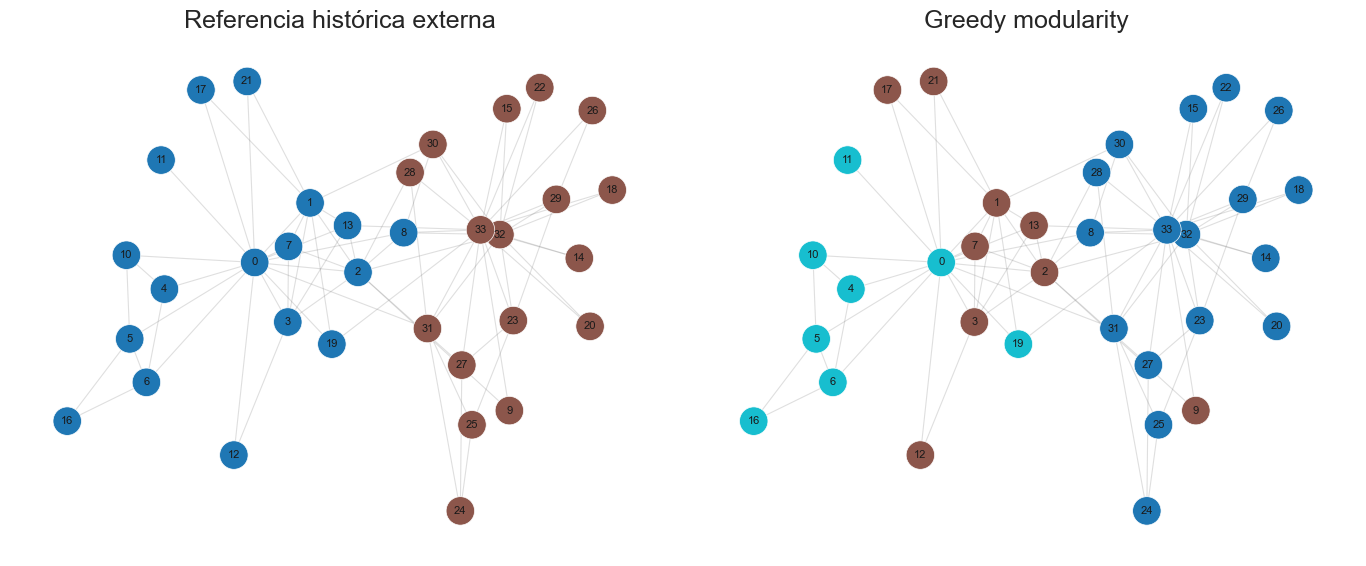

In [17]:
greedy_part = run_greedy_modularity(G_karate)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_partition_on_axis(axes[0], G_karate, karate_pos, karate_external, "Referencia histórica externa", labels=True)
plot_partition_on_axis(axes[1], G_karate, karate_pos, greedy_part, "Greedy modularity", labels=True)
plt.tight_layout()
plt.show()


,method,reference_seed,mean_ARI_between_seeds,mean_NMI_between_seeds,ARI_vs_hist_ref,NMI_vs_hist_ref
0,louvain,1,0.8603,0.9057,0.5089,0.6000
1,leiden,0,1.0000,1.0000,0.4646,0.5878


Método principal del caso Karate: leiden


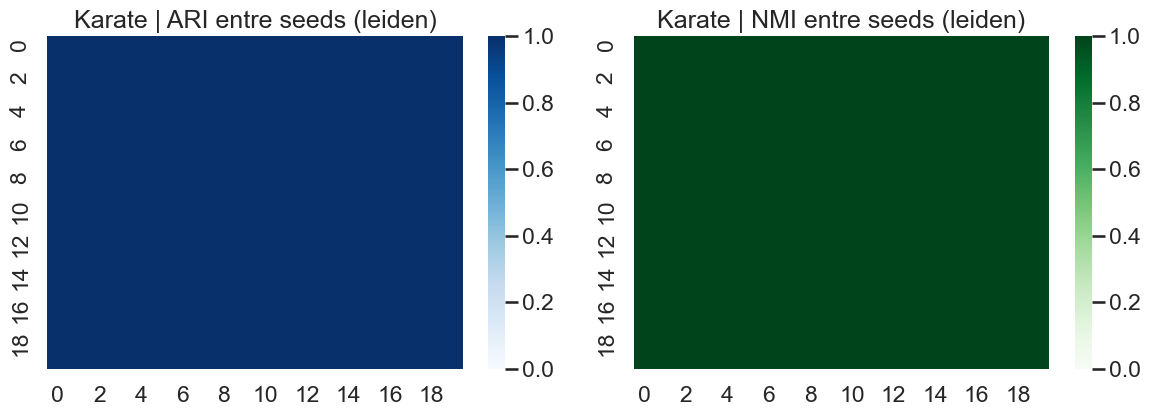

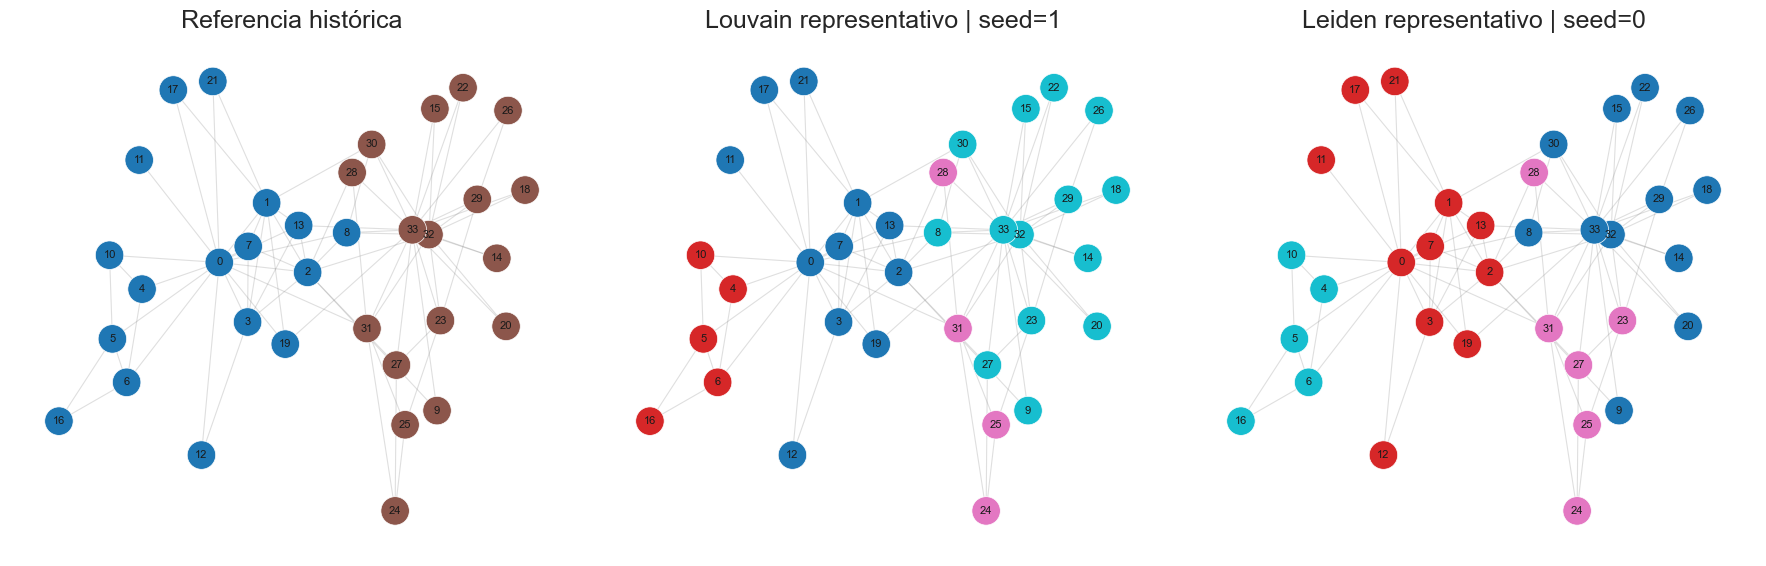

In [18]:
seeds = list(range(20))

karate_louvain = summarize_method_over_seeds(
    G_karate, method="louvain", seeds=seeds, resolution=1.0, weight=None, external_labels=karate_external
)

karate_summaries = [
    {
        "method": "louvain",
        "reference_seed": karate_louvain["reference_seed"],
        "mean_ARI_between_seeds": karate_louvain["mean_ARI"],
        "mean_NMI_between_seeds": karate_louvain["mean_NMI"],
        "ARI_vs_hist_ref": float(
            karate_louvain["df"].loc[
                karate_louvain["df"]["seed"] == karate_louvain["reference_seed"], "ARI_vs_hist"
            ].iloc[0]
        ),
        "NMI_vs_hist_ref": float(
            karate_louvain["df"].loc[
                karate_louvain["df"]["seed"] == karate_louvain["reference_seed"], "NMI_vs_hist"
            ].iloc[0]
        ),
    }
]

karate_leiden = None
if LEIDEN_OK:
    karate_leiden = summarize_method_over_seeds(
        G_karate, method="leiden", seeds=seeds, resolution=1.0, weight=None, external_labels=karate_external
    )
    karate_summaries.append(
        {
            "method": "leiden",
            "reference_seed": karate_leiden["reference_seed"],
            "mean_ARI_between_seeds": karate_leiden["mean_ARI"],
            "mean_NMI_between_seeds": karate_leiden["mean_NMI"],
            "ARI_vs_hist_ref": float(
                karate_leiden["df"].loc[
                    karate_leiden["df"]["seed"] == karate_leiden["reference_seed"], "ARI_vs_hist"
                ].iloc[0]
            ),
            "NMI_vs_hist_ref": float(
                karate_leiden["df"].loc[
                    karate_leiden["df"]["seed"] == karate_leiden["reference_seed"], "NMI_vs_hist"
                ].iloc[0]
            ),
        }
    )

karate_summary_df = pd.DataFrame(karate_summaries)
display(karate_summary_df.style.format({"mean_ARI_between_seeds": "{:.4f}", "mean_NMI_between_seeds": "{:.4f}", "ARI_vs_hist_ref": "{:.4f}", "NMI_vs_hist_ref": "{:.4f}"}))

primary_karate = karate_leiden if karate_leiden is not None else karate_louvain
print("Método principal del caso Karate:", primary_karate["method"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(primary_karate["ari"].astype(float), vmin=0, vmax=1, cmap="Blues", ax=axes[0])
axes[0].set_title(f"Karate | ARI entre seeds ({primary_karate['method']})")
sns.heatmap(primary_karate["nmi"].astype(float), vmin=0, vmax=1, cmap="Greens", ax=axes[1])
axes[1].set_title(f"Karate | NMI entre seeds ({primary_karate['method']})")
plt.tight_layout()
plt.show()

if karate_leiden is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    plot_partition_on_axis(axes[0], G_karate, karate_pos, karate_external, "Referencia histórica", labels=True)
    plot_partition_on_axis(
        axes[1],
        G_karate,
        karate_pos,
        karate_louvain["reference_partition"],
        f"Louvain representativo | seed={karate_louvain['reference_seed']}",
        labels=True,
    )
    plot_partition_on_axis(
        axes[2],
        G_karate,
        karate_pos,
        karate_leiden["reference_partition"],
        f"Leiden representativo | seed={karate_leiden['reference_seed']}",
        labels=True,
    )
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plot_partition_on_axis(axes[0], G_karate, karate_pos, karate_external, "Referencia histórica", labels=True)
    plot_partition_on_axis(
        axes[1],
        G_karate,
        karate_pos,
        karate_louvain["reference_partition"],
        f"Louvain representativo | seed={karate_louvain['reference_seed']}",
        labels=True,
    )
plt.tight_layout()
plt.show()


### Lectura del caso Karate

**1. ¿La partición representativa coincide con la referencia histórica?**

No necesariamente. Eso no debe leerse automáticamente como “fracaso” del algoritmo. La referencia histórica captura una separación concreta del club; `Louvain` y `Leiden`, en cambio, están leyendo estructura topológica según un criterio relacional. Si coinciden mucho, eso es informativo. Si no coinciden exactamente, también puede serlo: la red puede sugerir una escala algo distinta de agrupación.

**2. ¿Qué muestra la comparación Louvain vs Leiden?**

Si ambos métodos entregan particiones representativas parecidas, eso refuerza la lectura de que la estructura modular es robusta al algoritmo. Si difieren, la pregunta correcta no es “quién ganó”, sino qué definición operacional de comunidad está privilegiando cada método.

**3. ¿Qué conviene reportar en un proyecto?**

Conviene reportar una **partición representativa por acuerdo** y no la corrida con mayor `Q` elegida a posteriori. Esa decisión es más coherente con la teoría de estabilidad, evita `cherry-picking` y deja un criterio defendible frente a cambios de `seed`.


## 2. Caso B | Les Misérables

Este segundo caso es el que más se parece al flujo que luego se usará en proyectos:

- comparar representación ponderada vs no ponderada;
- resumir estabilidad entre `seeds`;
- elegir una partición representativa por consenso;
- revisar sensibilidad a `resolution`;
- y solo entonces pasar a interpretación descriptiva.


In [7]:
G = nx.les_miserables_graph()
G_unweighted = nx.Graph()
G_unweighted.add_nodes_from(G.nodes())
G_unweighted.add_edges_from(G.edges())

stats = pd.DataFrame([{
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
    "density": round(nx.density(G), 4),
    "weighted": nx.is_weighted(G),
    "avg_degree": round(np.mean([d for _, d in G.degree()]), 2),
    "avg_strength": round(np.mean([d for _, d in G.degree(weight="weight")]), 2),
}])
display(stats)

strengths = dict(G.degree(weight="weight"))
top_strength = pd.DataFrame(
    [{"node": n, "strength": strengths[n], "degree": G.degree(n)} for n in G.nodes()]
).sort_values(["strength", "degree"], ascending=False)
display(top_strength.head(12))
pos = nx.spring_layout(G, seed=42, weight="weight")
top_labels = set(top_strength.head(15)["node"])


,nodes,edges,density,weighted,avg_degree,avg_strength
0,77,254,0.0868,True,6.6,21.3


,node,strength,degree
10,Valjean,158,36
55,Marius,104,19
58,Enjolras,91,15
62,Courfeyrac,84,13
26,Cosette,68,11
59,Combeferre,68,11
64,Bossuet,66,13
25,Thenardier,61,16
48,Gavroche,56,22
27,Javert,47,17


,method,reference_seed,mean_ARI_between_seeds,mean_NMI_between_seeds,reference_modularity,reference_n_communities
0,louvain,3,0.9562,0.9688,0.5654,6
1,leiden,0,0.9814,0.9876,0.5667,6


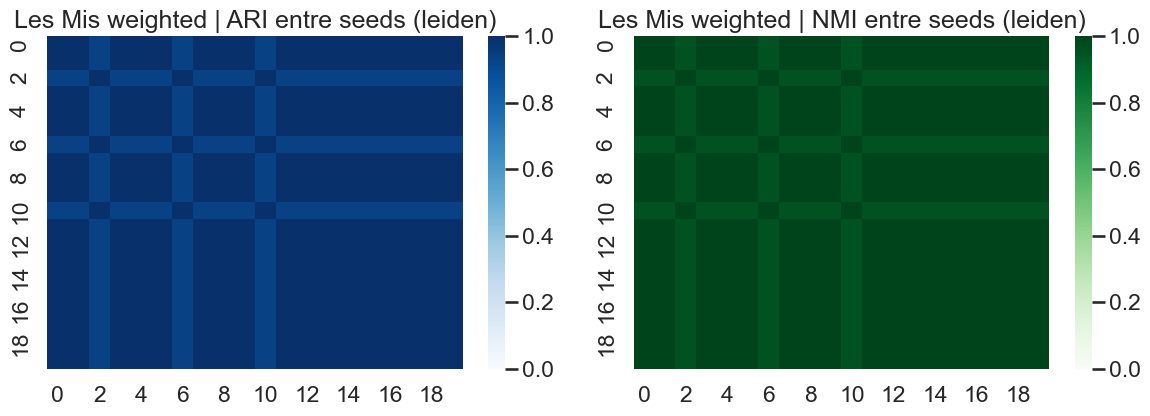

Acuerdo entre particiones representativas Louvain vs Leiden: {'ARI': 0.8936, 'NMI': 0.9247}
Método principal para el resto del caso Les Mis: leiden


In [8]:
weighted_results = {
    "louvain": summarize_method_over_seeds(G, method="louvain", seeds=seeds, resolution=1.0, weight="weight")
}
if LEIDEN_OK:
    weighted_results["leiden"] = summarize_method_over_seeds(G, method="leiden", seeds=seeds, resolution=1.0, weight="weight")

weighted_summary = []
for method, result in weighted_results.items():
    weighted_summary.append(
        {
            "method": method,
            "reference_seed": result["reference_seed"],
            "mean_ARI_between_seeds": result["mean_ARI"],
            "mean_NMI_between_seeds": result["mean_NMI"],
            "reference_modularity": float(
                result["df"].loc[result["df"]["seed"] == result["reference_seed"], "modularity"].iloc[0]
            ),
            "reference_n_communities": int(
                result["df"].loc[result["df"]["seed"] == result["reference_seed"], "n_communities"].iloc[0]
            ),
        }
    )

weighted_summary_df = pd.DataFrame(weighted_summary)
display(weighted_summary_df.style.format({"mean_ARI_between_seeds": "{:.4f}", "mean_NMI_between_seeds": "{:.4f}", "reference_modularity": "{:.4f}"}))

primary_method = "leiden" if LEIDEN_OK else "louvain"
weighted_primary = weighted_results[primary_method]
weighted_ref_seed = weighted_primary["reference_seed"]
weighted_ref = weighted_primary["reference_partition"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(weighted_primary["ari"].astype(float), vmin=0, vmax=1, cmap="Blues", ax=axes[0])
axes[0].set_title(f"Les Mis weighted | ARI entre seeds ({primary_method})")
sns.heatmap(weighted_primary["nmi"].astype(float), vmin=0, vmax=1, cmap="Greens", ax=axes[1])
axes[1].set_title(f"Les Mis weighted | NMI entre seeds ({primary_method})")
plt.tight_layout()
plt.show()

if LEIDEN_OK:
    ari_l = adjusted_rand_score(
        [weighted_results["louvain"]["reference_partition"][n] for n in sorted(G.nodes())],
        [weighted_results["leiden"]["reference_partition"][n] for n in sorted(G.nodes())],
    )
    nmi_l = normalized_mutual_info_score(
        [weighted_results["louvain"]["reference_partition"][n] for n in sorted(G.nodes())],
        [weighted_results["leiden"]["reference_partition"][n] for n in sorted(G.nodes())],
    )
    print("Acuerdo entre particiones representativas Louvain vs Leiden:",
          {"ARI": round(ari_l, 4), "NMI": round(nmi_l, 4)})

print("Método principal para el resto del caso Les Mis:", primary_method)


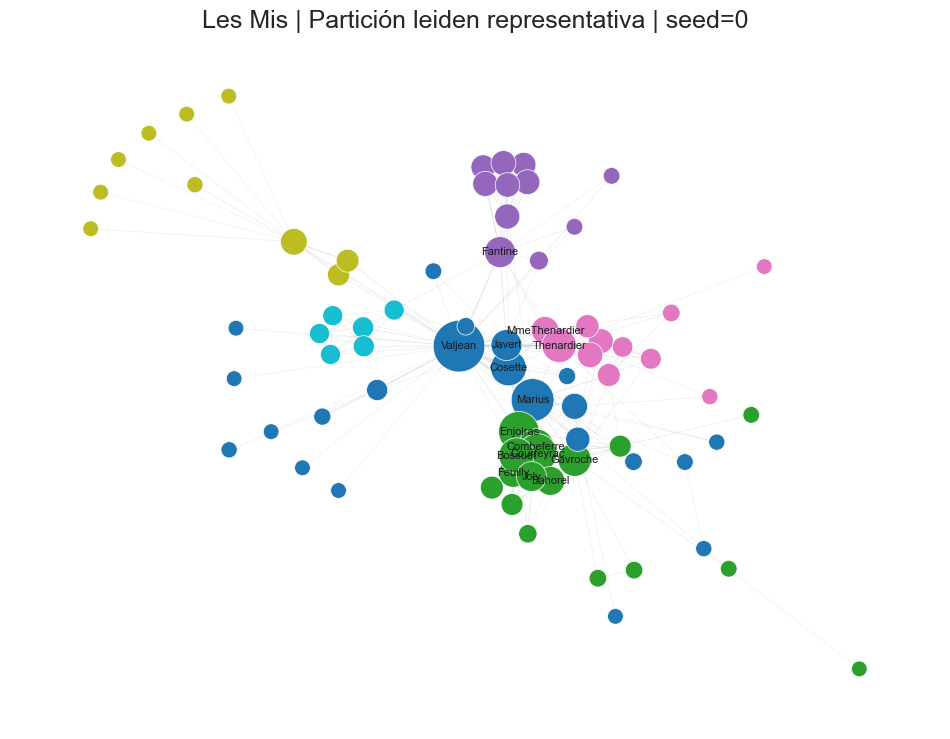

In [9]:
plt.figure(figsize=(12, 9))
edge_widths = [0.25 + 0.08 * G[u][v].get("weight", 1) for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, alpha=0.18, width=edge_widths, edge_color="gray")
groups = sorted(set(weighted_ref.values()))
cmap = plt.cm.get_cmap("tab10", max(len(groups), 3))
colors = {g: cmap(i) for i, g in enumerate(groups)}
node_colors = [colors[weighted_ref[n]] for n in G.nodes()]
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=[120 + 8 * strengths[n] for n in G.nodes()],
    edgecolors="white",
    linewidths=0.5,
)
nx.draw_networkx_labels(G, pos, labels={n: n for n in top_labels}, font_size=8)
plt.title(f"Les Mis | Partición {primary_method} representativa | seed={weighted_ref_seed}")
plt.axis("off")
plt.show()


In [10]:
binary_result = summarize_method_over_seeds(
    G_unweighted, method=primary_method, seeds=seeds, resolution=1.0, weight="weight"
)
binary_ref_seed = binary_result["reference_seed"]
binary_ref = binary_result["reference_partition"]

ari = adjusted_rand_score(
    [weighted_ref[n] for n in sorted(G.nodes())],
    [binary_ref[n] for n in sorted(G.nodes())],
)
nmi = normalized_mutual_info_score(
    [weighted_ref[n] for n in sorted(G.nodes())],
    [binary_ref[n] for n in sorted(G.nodes())],
)

compare_df = pd.DataFrame(
    [
        {
            "representation": "weighted",
            "method": primary_method,
            "reference_seed": weighted_ref_seed,
            "mean_ARI_within": weighted_primary["mean_ARI"],
            "reference_modularity": partition_modularity(G, weighted_ref, weight="weight"),
            "n_communities": len(set(weighted_ref.values())),
        },
        {
            "representation": "unweighted",
            "method": primary_method,
            "reference_seed": binary_ref_seed,
            "mean_ARI_within": binary_result["mean_ARI"],
            "reference_modularity": partition_modularity(G_unweighted, binary_ref, weight=None),
            "n_communities": len(set(binary_ref.values())),
        },
    ]
)
display(compare_df.style.format({"mean_ARI_within": "{:.4f}", "reference_modularity": "{:.4f}"}))
print(f"{primary_method.capitalize()} weighted vs unweighted | ARI:", round(ari, 4), "| NMI:", round(nmi, 4))


,representation,method,reference_seed,mean_ARI_within,reference_modularity,n_communities
0,weighted,leiden,0,0.9814,0.5667,6
1,unweighted,leiden,0,1.0000,0.5600,6


Leiden weighted vs unweighted | ARI: 0.7354 | NMI: 0.8533


### Comparación entre representación ponderada y no ponderada

Aquí comparamos el mismo método (`Leiden`) sobre dos representaciones de la misma red:

- **weighted**: se usan los pesos de los enlaces;
- **unweighted**: se ignoran los pesos y solo se conserva la existencia del enlace.

La idea es ver **cuánto cambia la partición cuando cambiamos la representación del grafo**.

---

### Qué muestra la tabla

Para cada representación se reporta:

- la `seed` elegida como referencia;
- el **acuerdo promedio interno** entre corridas del mismo método (`mean_ARI_within`);
- la modularidad de la partición de referencia;
- y el número de comunidades detectadas.

La lectura es:

- en la red **weighted**, Leiden es muy estable entre corridas (`mean_ARI_within = 0.9814`);
- en la red **unweighted**, la estabilidad es incluso total (`mean_ARI_within = 1.0000`);
- en ambos casos, la partición de referencia tiene **6 comunidades**;
- la modularidad es muy parecida en ambas representaciones:
  - weighted: $0.5667$
  - unweighted: $0.5600$

Eso sugiere que, dentro de cada representación, el método está produciendo soluciones muy consistentes.

---

### Qué muestra la comparación final

Luego comparamos directamente las dos particiones de referencia:

- **ARI = 0.7354**
- **NMI = 0.8533**

Esto indica que las dos particiones son **bastante parecidas, pero no idénticas**.

- El **NMI alto** muestra que comparten bastante información estructural;
- el **ARI más bajo** indica que no coinciden perfectamente nodo por nodo.

En otras palabras:

> al ignorar los pesos, la estructura general de comunidades se conserva bastante, pero algunos nodos cambian de asignación.

---

### Interpretación 

La lección metodológica es importante:

> **la representación de la red sí importa**.

Aunque aquí weighted y unweighted producen el mismo número de comunidades y resultados globalmente similares, la partición no es exactamente la misma. Eso significa que los pesos contienen información que afecta, al menos en parte, la mesoestructura detectada.

Entonces, si la pregunta sustantiva depende de la **intensidad** de los vínculos, no es inocuo binarizar la red. Puede que la estructura gruesa se mantenga, pero detalles relevantes de la partición cambien.

---


>En este ejemplo, `Leiden` es muy estable tanto con pesos como sin pesos, y la estructura general detectada es bastante similar. Pero la comparación entre ambas particiones muestra que **cambiar la representación no es neutro**: los pesos no alteran completamente el panorama, pero sí modifican parte de la asignación comunitaria.

,resolution,modularity,n_communities
0,0.500000,0.5472,5
1,0.800000,0.5667,6
2,1.000000,0.5667,6
3,1.200000,0.5659,7
4,1.500000,0.5644,7
5,2.000000,0.5353,11


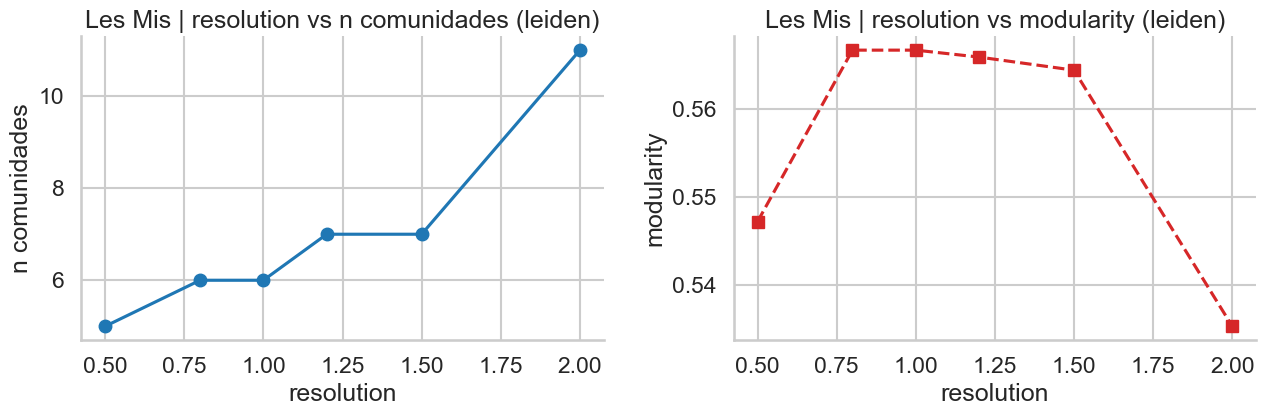

In [11]:
# Mantenemos fija la seed representativa para aislar el efecto de resolution.
resolution_grid = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
resolution_rows = []
for gamma in resolution_grid:
    part = run_partition_method(G, method=primary_method, seed=weighted_ref_seed, resolution=gamma, weight="weight")
    resolution_rows.append(
        {
            "resolution": gamma,
            "modularity": partition_modularity(G, part, weight="weight"),
            "n_communities": len(set(part.values())),
        }
    )
resolution_df = pd.DataFrame(resolution_rows)
display(resolution_df.style.format({"modularity": "{:.4f}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(
    resolution_df["resolution"],
    resolution_df["n_communities"],
    marker="o",
    color="#1f77b4",
)
axes[0].set_title(f"Les Mis | resolution vs n comunidades ({primary_method})")
axes[0].set_xlabel("resolution")
axes[0].set_ylabel("n comunidades")

axes[1].plot(
    resolution_df["resolution"],
    resolution_df["modularity"],
    marker="s",
    linestyle="--",
    color="#d62728",
)
axes[1].set_title(f"Les Mis | resolution vs modularity ({primary_method})")
axes[1].set_xlabel("resolution")
axes[1].set_ylabel("modularity")

plt.tight_layout()
plt.show()


### Efecto del parámetro `resolution` en Leiden

Aquí mantenemos fija la misma `seed` y cambiamos solo el parámetro **`resolution`**. La idea es aislar una sola pregunta:

> **¿cómo cambia la partición cuando cambiamos la escala a la que el algoritmo busca comunidades?**

---

### Qué muestra la tabla

Para cada valor de `resolution` se reportan dos cosas:

- la **modularidad** de la partición encontrada;
- el **número de comunidades** detectadas.

La pauta general die:

- cuando `resolution` es baja, el algoritmo encuentra **menos comunidades**;
- a medida que `resolution` sube, el número de comunidades **aumenta**;
- al mismo tiempo, la modularidad **no sube indefinidamente**: alcanza un máximo intermedio y luego empieza a bajar.

---

### Cómo leer el gráfico de la izquierda

El panel izquierdo muestra:

- `resolution = 0.5`  $\rightarrow$  **5 comunidades**
- `resolution = 0.8` y `1.0`  $\rightarrow$  **6 comunidades**
- `resolution = 1.2` y `1.5`  $\rightarrow$  **7 comunidades**
- `resolution = 2.0`  $\rightarrow$  **11 comunidades**

Esto ilustra la función práctica del parámetro:

> **`resolution` controla la escala de la partición.**

- resoluciones más bajas tienden a **fusionar** grupos;
- resoluciones más altas tienden a **subdividir** la red en más comunidades.

---

### Cómo leer el gráfico de la derecha

El panel derecho muestra que la modularidad:

- sube desde `0.5472` en `resolution = 0.5`,
- alcanza su mejor nivel alrededor de `0.8–1.0` (`0.5667`),
- luego se mantiene muy parecida en `1.2–1.5`,
- y cae con más claridad en `2.0` (`0.5353`).

La lectura importante es:

> **partir la red en más comunidades no implica necesariamente una mejor partición en términos de modularidad.**

De hecho, cuando la resolución es demasiado alta, el algoritmo empieza a fragmentar más la red, pero esa fragmentación extra ya no mejora el criterio global; al contrario, lo empeora.

---

### Qué nos enseña este resultado

Este ejemplo muestra un compromiso clásico:

- si usamos una resolución muy baja, podemos **fusionar demasiado**;
- si usamos una resolución muy alta, podemos **fragmentar demasiado**;
- por eso suele haber una zona intermedia donde la partición parece más razonable también en términos de modularidad.

En esta red (`Les Mis`), esa zona intermedia parece estar cerca de:

- `resolution = 0.8`
- `resolution = 1.0`

porque allí la modularidad es máxima y el número de comunidades todavía no explota.

---

### Idea metodológica para quedarse

El parámetro `resolution` no es un detalle técnico menor. Cambia la **escala mesoestructural** que el algoritmo devuelve.

Por eso, al usar métodos como Leiden o Louvain, no conviene tratar una única corrida con una única resolución como si revelara “la” partición verdadera. Más bien, conviene mirar:

- cómo cambia el número de comunidades;
- cómo cambia la modularidad;
- y si existe una región de valores donde la solución se vea relativamente estable e interpretable.

---


> Al subir `resolution`, Leiden tiende a dividir la red en más comunidades. Pero más comunidades no significa automáticamente mejor partición: en este ejemplo, la modularidad mejora hasta una zona intermedia y luego cae cuando la fragmentación se vuelve excesiva.

In [12]:
profile_df = pd.DataFrame(
    [
        {
            "node": n,
            "community": weighted_ref[n],
            "degree": G.degree(n),
            "strength": G.degree(n, weight="weight"),
        }
        for n in G.nodes()
    ]
).sort_values(["community", "strength", "degree"], ascending=[True, False, False])
display(profile_df.groupby("community").head(6))


,node,community,degree,strength
10,Valjean,0,36,158
55,Marius,0,19,104
26,Cosette,0,11,68
27,Javert,0,17,47
49,Gillenormand,0,7,29
51,MlleGillenormand,0,7,23
58,Enjolras,1,15,91
62,Courfeyrac,1,13,84
59,Combeferre,1,11,68
64,Bossuet,1,13,66


## 3. Cierre y transferencia al caso aplicado

Lo que este práctico debe dejar instalado es un protocolo:

1. definir la representación;
2. correr el algoritmo con múltiples `seeds`;
3. resumir estabilidad;
4. elegir una partición representativa por acuerdo;
5. revisar sensibilidad a `resolution`;
6. contrastar `Louvain` y `Leiden` si ambos están disponibles;
7. recién después interpretar.


**1. ¿Qué deja `Les Mis` como lección principal?**

Que incluso en una red bien conocida, la partición depende de la representación. Weighted y unweighted no son el mismo objeto analítico y, por tanto, no deben producirse ni interpretarse como si fuesen equivalentes.

**2. ¿Qué agrega `Leiden` a esta práctica?**

Agrega una referencia metodológica útil: permite comparar si la lectura modular cambia mucho al pasar de un heurístico estándar (`Louvain`) a uno que suele entregar comunidades internamente mejor conectadas. Si ambos convergen a una lectura parecida, la interpretación gana solidez.

**3. ¿Qué enseña la sensibilidad a `resolution`?**

Que no existe una escala universalmente correcta de comunidad. Al aumentar `resolution`, la partición tiende a hacerse más fina. La pregunta correcta no es “cuál es la resolución verdadera”, sino en qué rango la lectura sigue siendo estable y sustantivamente razonable.

**4. ¿Por qué este workflow sirve antes de compras públicas?**

Porque instala un hábito analítico correcto: primero se justifica el grafo, luego se evalúa estabilidad, después se prueba sensibilidad y solo al final se interpreta. Eso es exactamente lo que los estudiantes necesitarán al pasar de redes unipartitas nativas a proyecciones de compras públicas.

**5. ¿Qué error queremos evitar?**

Elegir la corrida con mayor modularidad y construir una historia cerrada alrededor de ella. Ese error es metodológicamente cómodo, pero es inconsistente con la teoría de la semana y débil para un proyecto serio.
